# **Power Line Problem: Gradient Descent**

In [3]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

### Dataset

In [4]:
X = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 5, 4, 5])

### Visualization

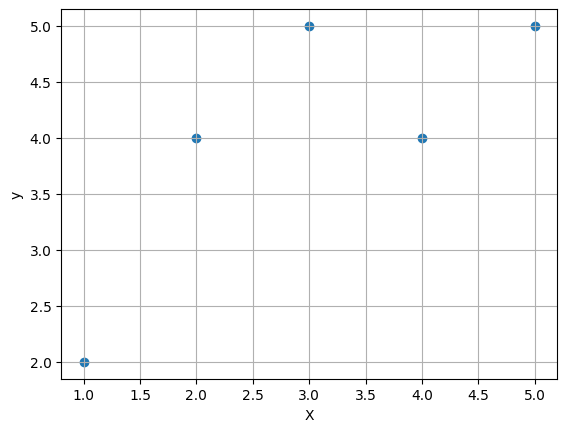

In [5]:
plt.grid()
plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.show()

### Cost Funtion

In [57]:
m, b = sp.symbols('m b')

J = (
    (m + b - 2)**2 +
    (2*m + b - 5)**2 +
    (3*m + b - 3)**2
)

J

(b + m - 2)**2 + (b + 2*m - 5)**2 + (b + 3*m - 3)**2

### Gradients

In [58]:
djdm = sp.diff(J, m)
djdb = sp.diff(J, b)

djdm, djdb

(12*b + 28*m - 42, 6*b + 12*m - 20)

### Define Gradient Descent Function

In [38]:
def gradient_descent(initial_m, initial_b, djdm, djdb, learning_rate=0.1, num_iterations=100):
    x, y = initial_m, initial_b
    history = [(x,y)]
    for _ in range(num_iterations):
        x = x - learning_rate * djdm.subs({m:x, b:y})
        y = y - learning_rate * djdb.subs({m:x, b:y})
        history.append((x,y))
    return x,y, history

### Computing Optimal $m$ and $b$.

In [52]:
optimal_m, optimal_b, history = gradient_descent(
    initial_b=5, 
    initial_m=5, 
    djdb=djdb, djdm=djdm,
    num_iterations=100,
    learning_rate=0.01
)

optimal_m, optimal_b, 

(0.275381024032589, 2.84331970122545)

### Define the optimal line

In [46]:
def line(x):
    return optimal_m * x + optimal_b

### Visualization

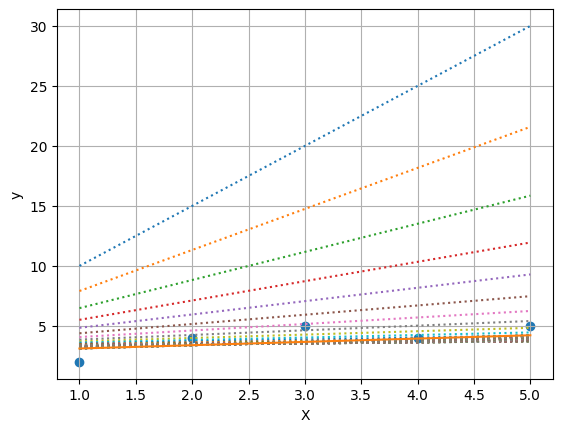

In [56]:
xs = np.linspace(1, 5, 100)
ys = line(xs)

plt.grid()

for candidate_m, candidate_b in history:
    candidate_line = lambda x: candidate_m * x + candidate_b
    plt.plot(xs, candidate_line(xs), linestyle=":")

plt.plot(xs, ys)
plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.show()